# Lezione 5.1: Fondamenti di Scikit-Learn con Bike Sharing

In questo notebook esploreremo i concetti fondamentali di **Scikit-Learn** applicandoli al nostro caso di studio reale: il dataset **European Bike Sharing**.

## Obiettivi
1.  Caricare e preparare i dati (Preprocessing).
2.  Capire la struttura `X` (Features) e `y` (Target).
3.  Utilizzare l'API Estimator per addestrare un modello di Regressione Lineare.
4.  Valutare il modello con metriche di base (MAE, RMSE).

## Step 1
accedi a Pgadmin ed utilizzano il query editor, posizionati sul dtwh bikesharing già creato e scrivi una query per trovare:
data_completa
mese
giorno_settimana
is_weekend
total_rental
avg_duration

## Step 2
scarica il risultato in un cvs e posizionalo nella stessa directory di questo Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione grafici
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Caricamento dei Dati


leggi i dati dal CSV.

In [2]:
# Caricamento dati da CSV (estratti dal DWH)
df = pd.read_csv("esercizio_sinistri_auto.csv")



df.head()


,eta_conducente,anni_patente,cilindrata_cc,fascia_oraria,costo_sinistro
0,56,30,1200,mattina,347.0
1,69,49,1200,pomeriggio,200.0
2,46,20,2500,pomeriggio,1219.0
3,32,13,1600,mattina,711.0
4,60,41,1400,pomeriggio,304.0


In [3]:
df['costo_sinistro'].describe()

count     400.000000
mean      942.075000
std       521.865249
min       200.000000
25%       509.500000
50%       893.500000
75%      1276.250000
max      2500.000000
Name: costo_sinistro, dtype: float64

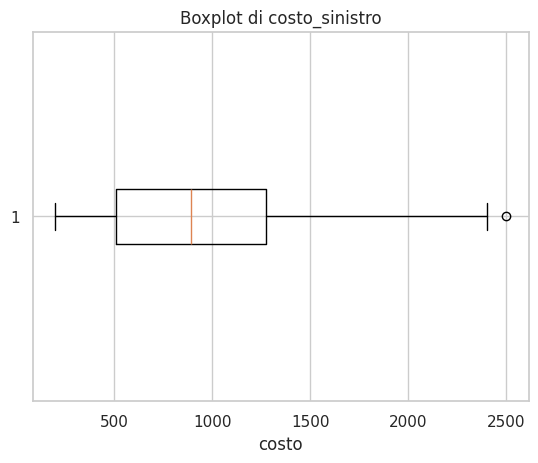

In [4]:
plt.boxplot(df['costo_sinistro'], vert=False)

plt.xlabel("costo")
plt.title("Boxplot di costo_sinistro")

plt.show()

In [5]:
# ================================
# PREPROCESSING: One-Hot Encoding della fascia oraria
# ================================

# Visualizziamo i valori possibili (controllo didattico)
df['fascia_oraria'].value_counts()   # Conta quante osservazioni per fascia oraria


fascia_oraria
mattina       122
pomeriggio    119
sera           92
notte          67
Name: count, dtype: int64

In [6]:
# Applichiamo il One-Hot Encoding
# columns=['fascia_oraria'],
# drop_first=True

df = pd.get_dummies(df, columns=['fascia_oraria']) # Trasforma la colonna categorica in colonne numeriche

# get_dummies() applica il One-Hot Encoding.
# Regola base:  Una colonna per ogni valore possibile della categoria

# Guarda i valori unici in fascia_oraria: ['mattina', 'pomeriggio', 'sera', 'notte']

# Crea una colonna per ciascun valore:
# fascia_oraria_mattina
# fascia_oraria_pomeriggio
# fascia_oraria_sera
# fascia_oraria_notte

# Riempie le colonne con 0 e 1

# Verifichiamo le nuove colonne
df.head()


,eta_conducente,anni_patente,cilindrata_cc,costo_sinistro,fascia_oraria_mattina,fascia_oraria_notte,fascia_oraria_pomeriggio,fascia_oraria_sera
0,56,30,1200,347.0,True,False,False,False
1,69,49,1200,200.0,False,False,True,False
2,46,20,2500,1219.0,False,False,True,False
3,32,13,1600,711.0,True,False,False,False
4,60,41,1400,304.0,False,False,True,False


## 2. Definizione di X e y

Nel Machine Learning supervisionato, dobbiamo separare:
*   **X (Features)**: Le variabili che usiamo per fare la previsione.
*   **y (Target)**: La variabile che vogliamo prevedere.

**Obiettivo**: Prevedere il numero totale di noleggi (`total_rentals`) basandoci sulle caratteristiche temporali.

In [7]:
# Selezioniamo le feature
features = [
    'eta_conducente',
    'anni_patente',
    'cilindrata_cc',
    'fascia_oraria_mattina',
    'fascia_oraria_notte',
    'fascia_oraria_pomeriggio',
    'fascia_oraria_sera'
]

target = 'costo_sinistro'

X = df[features]
y = df[target]

# verifichiamo la dimensione di X ed Y
print(f"Shape di X: {X.shape}")
print(f"Shape di y: {y.shape}")

Shape di X: (400, 7)
Shape di y: (400,)


## 3. Train-Test Split

Non dobbiamo mai valutare il modello sugli stessi dati usati per l'addestramento. Usiamo `train_test_split`.

In [8]:
from sklearn.model_selection import train_test_split

# Dividiamo: 80% Training, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# test_size=0.2
    # Dice quanto grande deve essere il test.
    # 0.2 = 20% dei dati va nel test.
    # Il resto (80%) va nel training.

# random_state=42
    # Serve per rendere la divisione “ripetibile”.
    # Senza random_state, ogni volta che esegui potresti ottenere uno split diverso.
    # Con random_state=42, lo split sarà sempre uguale (utile per confrontare risultati e non impazzire).

print(f"Training samples: {len(X_train)}")  # (quanti giorni nel train).
print(f"Test samples: {len(X_test)}")

Training samples: 320
Test samples: 80


## 4. Addestramento del Modello (Estimator API)

Useremo una **Regressione Lineare**. In Scikit-Learn, il flusso è sempre:
1.  Importare la classe.
2.  Istanziare l'oggetto (configurare iperparametri).
3.  Chiamare `.fit()` sui dati di training.

In [9]:
# 1. Importiamo la classe che utilizzeremo
from sklearn.linear_model import LinearRegression
# linear_model = modulo dove stanno i modelli lineari.
# LinearRegression = il modello specifico che userai.

# predizione = b
#       + w1·mese
#       + w2·giorno_settimana
#       + w3·is_weekend

# 1. Istanziazione
model = LinearRegression()

# 2. Fitting (Apprendimento)
model.fit(X_train, y_train)

# fit(...)
#     “Allena” il modello.
#     Gli fa imparare la relazione tra input e output.

# Il modello cerca i coefficienti w1, w2, w3 e b che minimizzano l’errore tra:
#    valori reali (y_train)   e  valori previsti dalla formula lineare

# Vediamo cosa ha imparato (i coefficienti)
print("Intercetta:", model.intercept_)
print("Coefficienti:", dict(zip(features, model.coef_)))

# Dopo l’addestramento il modello ha imparato:
#     model.coef_ → i pesi (w1, w2, w3)
#     model.intercept_ → l’intercetta (b)

# zip() è una funzione Python che accoppia elementi di due liste posizione per posizione.

Intercetta: 1244.0277989704819
Coefficienti: {'eta_conducente': np.float64(-15.30764403599537), 'anni_patente': np.float64(-2.5668668111721993), 'cilindrata_cc': np.float64(0.3858873128321392), 'fascia_oraria_mattina': np.float64(-191.71303553497873), 'fascia_oraria_notte': np.float64(437.866408288217), 'fascia_oraria_pomeriggio': np.float64(-207.64468810247723), 'fascia_oraria_sera': np.float64(-38.5086846507611)}


## 5. Previsione e Valutazione

Ora usiamo `.predict()` sui dati di test (che il modello non ha mai visto) e confrontiamo le previsioni con la realtà.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
# mean_absolute_error → MAE
# mean_squared_error → MSE (da cui RMSE)

# Generiamo previsioni
y_pred = model.predict(X_test)  # fa le previsioni.

# Parametri:
#     model → modello già allenato (fit fatto prima)
#     X_test → feature dei giorni di test

# Cosa restituisce:
#     y_pred → lista di numeri previsti

# Calcoliamo l'errore
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# mean_squared_error(y_test, y_pred) Calcola MSE: errore² = (reale − previsto)²

print(f"MAE (Errore Medio Assoluto): {mae:.2f}")
print(f"RMSE (Radice Errore Quadratico Medio): {rmse:.2f}")

MAE (Errore Medio Assoluto): 236.74
RMSE (Radice Errore Quadratico Medio): 296.51


## 6. Visualizzazione dei Risultati

Un grafico vale più di mille numeri. Vediamo quanto le previsioni si avvicinano alla realtà.

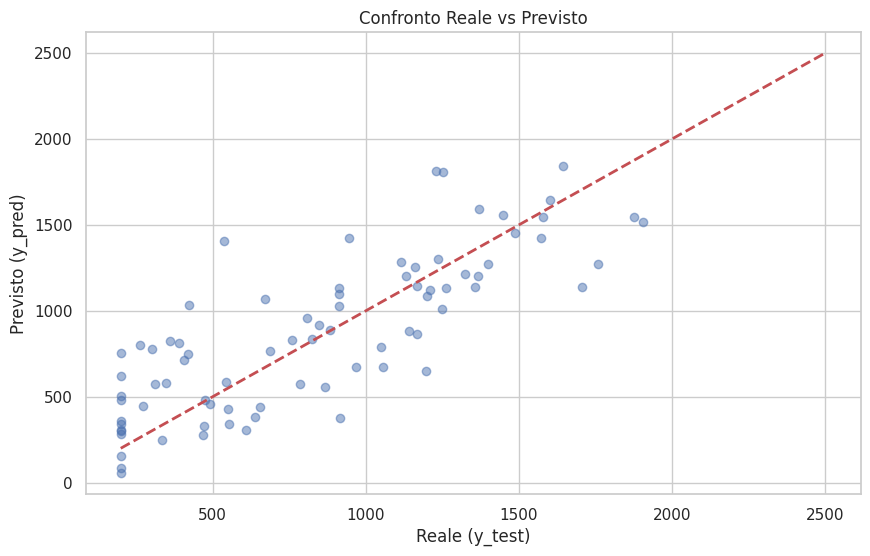

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Linea ideale
plt.xlabel('Reale (y_test)')
plt.ylabel('Previsto (y_pred)')
plt.title('Confronto Reale vs Previsto')
plt.show()